<a href="https://colab.research.google.com/github/Saroj-lab/AlbatrossPredict/blob/main/Albatross.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import pandas as pd
import numpy as np

In [45]:
df_test = pd.read_csv('/content/test.csv')
df_test.head()

,id,longitudCraneo,longitudPico,longitudNarina,anchoCraneo,altoPico,anchoPico,tarso,longAlaCerrada,longAlaAbierta,mediaEnvergadura,envergadura,peso
0,A70_2018,183.57,117.18,87.90,53.60,33.10,26.50,95.70,52.5,98.6,104.4,208.8,3.35
1,5C9_2018,166.60,105.05,80.63,51.64,31.31,26.10,88.82,50.7,93.4,101.4,202.8,2.43
2,5E1_2018,175.53,111.23,84.93,53.74,32.75,24.93,91.42,51.3,94.2,103.4,206.8,2.99
3,C58_2018,187.85,116.90,87.52,54.22,35.10,27.00,99.48,52.3,99.8,107.6,215.2,3.55
4,5E2_2018,182.67,116.40,87.24,54.57,33.59,25.40,96.43,53.4,100.3,110.1,220.2,3.06


In [46]:
df_train = pd.read_csv('/content/train.csv')
df_train.head()

,id,sexo,longitudCraneo,longitudPico,longitudNarina,anchoCraneo,altoPico,anchoPico,tarso,longAlaCerrada,longAlaAbierta,mediaEnvergadura,envergadura,peso
0,0J4_2016,H,174.18,106.85,80.19,52.43,30.20,23.26,88.74,51.0,95.7,104.2,208.4,2.38
1,A68_2016,H,171.12,104.59,79.45,51.14,30.61,24.04,90.22,50.5,94.4,102.2,204.4,2.14
2,E55_2015,H,174.69,106.83,82.14,49.09,30.60,26.47,91.42,52.7,96.6,105.2,210.4,2.50
3,7C7_2016,M,182.25,113.17,84.13,52.26,32.08,26.07,91.74,52.6,98.9,107.6,215.2,2.83
4,2C0_2018,H,173.70,105.19,80.37,49.20,34.00,27.12,87.77,50.8,94.5,103.7,207.4,2.73


In [47]:
df_train.shape

(94, 14)

In [48]:
df_test.shape

(41, 13)

In [49]:
df_train.info

<bound method DataFrame.info of           id sexo  longitudCraneo  longitudPico  longitudNarina  anchoCraneo  \
0   0J4_2016    H          174.18        106.85           80.19        52.43   
1   A68_2016    H          171.12        104.59           79.45        51.14   
2   E55_2015    H          174.69        106.83           82.14        49.09   
3   7C7_2016    M          182.25        113.17           84.13        52.26   
4   2C0_2018    H          173.70        105.19           80.37        49.20   
..       ...  ...             ...           ...             ...          ...   
89  H50_2017    H          168.18        106.70           80.30        49.20   
90  3C0_2015    H          173.95        106.88           81.77        50.27   
91  A62_2016    M          181.01        109.98           82.95        55.47   
92  H24_2015    M          181.51        112.57           85.58        54.11   
93  1J4_2018    H          170.56        106.07           79.91        51.16   

    altoPico  anchoPico  tarso  longAlaCerrada  longAlaAbierta  \
0      30.20      23.26  88.74            51.0            95.7   
1      30.61      24.04  90.22            50.5            94.4   
2      30.60      26.47  91.42            52.7            96.6   
3      32.08      26.07  91.74            52.6            98.9   
4      34.00      27.12  87.77            50.8            94.5   
..       ...        ...    ...             ...             ...   
89     31.30      24.50  91.30            53.4            98.6   
90     32.54      25.65  88.64            52.4            96.0   
91     32.84      25.84  90.78            51.4            96.0   
92     32.60      26.02  93.11            53.0            98.0   
93     33.17      24.68  90.12            50.7            94.7   

    mediaEnvergadura  envergadura  peso  
0              104.2        208.4  2.38  
1              102.2        204.4  2.14  
2              105.2        210.4  2.50  
3              107.6        215.2  2.83  
4              103.7        207.4  2.73  
..               ...          ...   ...  
89             105.9        211.8  2.73  
90             105.9        211.8  2.65  
91             105.4        210.8  2.55  
92             107.4        214.8  3.10  
93             102.6        205.2  2.67  

[94 rows x 14 columns]>

In [50]:
df_test.info

<bound method DataFrame.info of           id  longitudCraneo  longitudPico  longitudNarina  anchoCraneo  \
0   A70_2018          183.57        117.18           87.90        53.60   
1   5C9_2018          166.60        105.05           80.63        51.64   
2   5E1_2018          175.53        111.23           84.93        53.74   
3   C58_2018          187.85        116.90           87.52        54.22   
4   5E2_2018          182.67        116.40           87.24        54.57   
5   5C2_2018          179.50        112.92           84.78        52.67   
6   E21_2018          185.32        116.08           89.96        56.75   
7   1C2_2018          184.17        115.44           88.14        53.63   
8   C90_2018          177.55        111.40           84.75        52.93   
9   A87_2018          180.64        111.54           84.52        53.90   
10  2H7_2018          177.63        112.24           84.61        48.80   
11  C99_2018          172.91        107.08           81.24        51.73   
12  6C2_2017          175.50        105.30           77.80        49.70   
13  E21_2017          180.91        116.40           88.40        56.60   
14  6C1_2016          173.07        109.87           83.25        52.20   
15  6E0_2016          170.71        104.55           80.14        54.50   
16  2A2_2016          177.83        106.46           81.21        52.50   
17  J46_2016          172.11        104.93           79.41        51.63   
18  H67_2016          181.87        107.69           82.84        50.88   
19  E93_2016          170.60        100.81           75.23        48.69   
20  A67_2016          177.01        109.77           81.90        50.79   
21  H19_2016          172.50        110.03           80.84        49.08   
22  B68_2016          173.16        107.77           80.04        52.09   
23  E04_2016          179.85        112.78           85.66        57.33   
24  C91_2016          178.79        110.24           82.21        54.53   
25  8C3_2016          177.43        111.70           83.86        54.53   
26  J45_2016          179.23        108.20           81.22        54.41   
27  7E9_2016          181.96        117.44           87.36        53.90   
28  1E3_2016          186.02        114.94           85.64        52.60   
29  0J5_2016          187.64        114.76           85.34        51.60   
30  H23_2016          186.43        116.53           87.37        52.84   
31  E11_2016          193.22        116.85           88.14        53.48   
32  4A5_2016          179.56        109.46           83.79        55.50   
33  K89_2016          178.77        113.45           82.41        54.01   
34  3A2_2015          168.18        101.78           77.58        54.27   
35  2C3_2015          178.83        107.60           81.57        52.25   
36  C43_2015          171.75        109.09           83.63        51.97   
37  0C4_2015          174.77        106.23           80.12        49.62   
38  A56_2015          185.22        116.47           88.57        56.50   
39  9B6_2015          189.43        117.22           90.33        54.31   
40  H72_2015          182.11        111.77           84.76        53.19   

    altoPico  anchoPico  tarso  longAlaCerrada  longAlaAbierta  \
0      33.10      26.50  95.70            52.5            98.6   
1      31.31      26.10  88.82            50.7            93.4   
2      32.75      24.93  91.42            51.3            94.2   
3      35.10      27.00  99.48            52.3            99.8   
4      33.59      25.40  96.43            53.4           100.3   
5      33.86      28.35  95.32            53.1            99.6   
6      32.78      26.03  97.79            53.5           102.0   
7      35.12      27.58  95.87            51.1            97.3   
8      34.55      25.90  90.84            50.6            97.7   
9      33.95      27.02  93.96            53.6           100.8   
10     33.01      26.01  89.29            51.3            98.8   
11     32.60      24.97  

In [51]:
df_train.duplicated().sum()

np.int64(0)

In [52]:
df_test.duplicated().sum()

np.int64(0)

In [53]:
df_train.isnull().sum()

,0
id,0
sexo,0
longitudCraneo,0
longitudPico,0
longitudNarina,0
anchoCraneo,0
altoPico,0
anchoPico,0
tarso,0
longAlaCerrada,0


In [54]:
# Calculate median from training set
peso_median = df_train['peso'].median()

# Fill missing values
df_train['peso'] = df_train['peso'].fillna(peso_median)
df_test['peso'] = df_test['peso'].fillna(peso_median)

In [55]:
df_train.isnull().sum()

,0
id,0
sexo,0
longitudCraneo,0
longitudPico,0
longitudNarina,0
anchoCraneo,0
altoPico,0
anchoPico,0
tarso,0
longAlaCerrada,0


In [56]:
df_test.isnull().sum()

,0
id,0
longitudCraneo,0
longitudPico,0
longitudNarina,0
anchoCraneo,0
altoPico,0
anchoPico,0
tarso,0
longAlaCerrada,0
longAlaAbierta,0


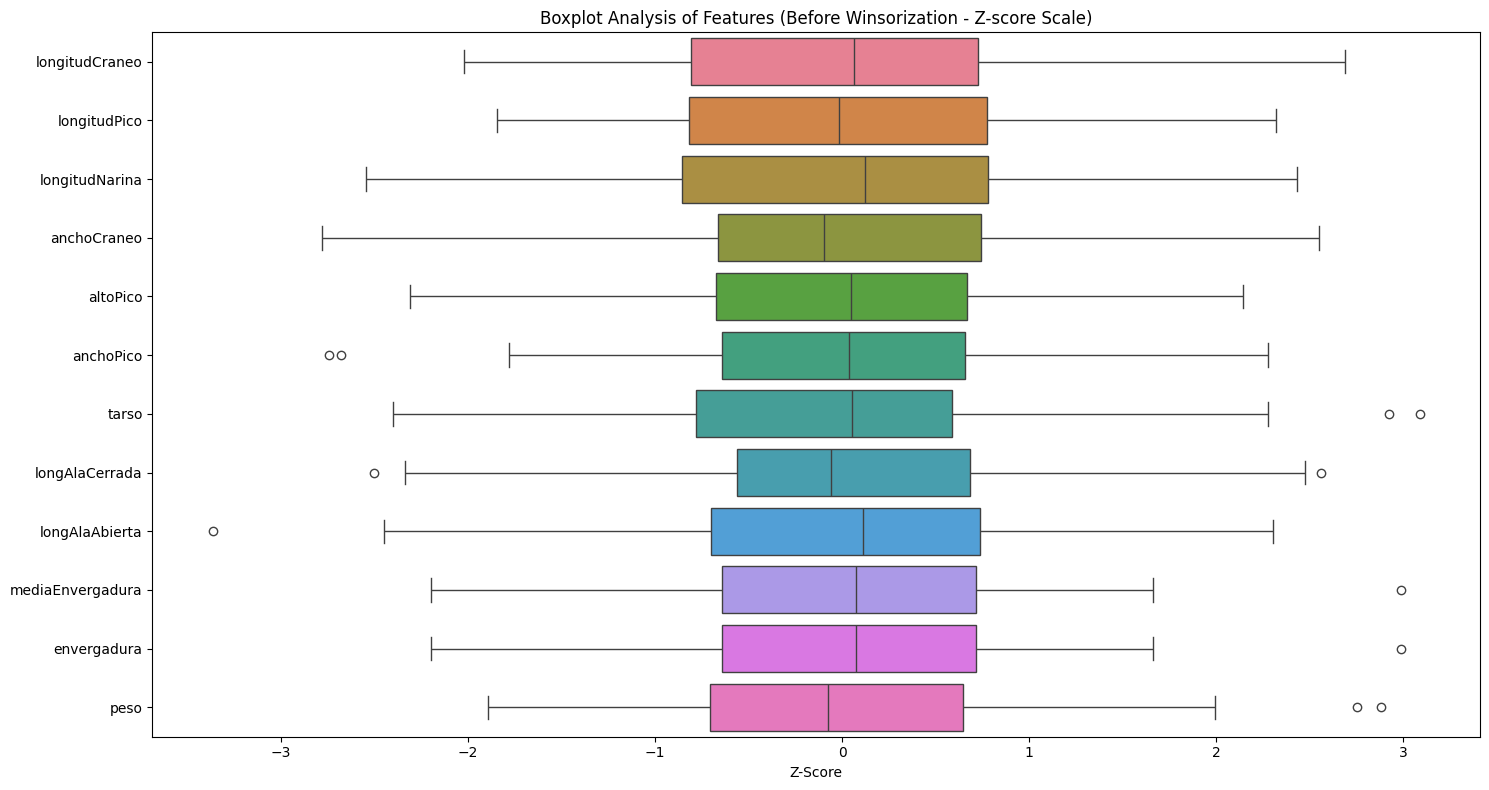

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical features (excluding non-predictive ID and binary target)
num_cols = [c for c in df_train.columns if c not in ['id', 'sexo']]

# Visualizing distributions with boxplots before processing
plt.figure(figsize=(15, 8))
# Standardize features temporarily just for plotting on a common visual scale
df_scaled_viz = (df_train[num_cols] - df_train[num_cols].mean()) / df_train[num_cols].std()
sns.boxplot(data=df_scaled_viz, orient='h')
plt.title("Boxplot Analysis of Features (Before Winsorization - Z-score Scale)")
plt.xlabel("Z-Score")
plt.tight_layout()
plt.show()

In [58]:
# Analyze and print outlier counts per feature based on training set IQR
outlier_summary = {}

for col in num_cols:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers in df_train
    outliers_count = ((df_train[col] < lower_bound) | (df_train[col] > upper_bound)).sum()
    outlier_summary[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outliers Count': outliers_count
    }

# Display summary in a clean DataFrame
import pandas as pd
df_outliers = pd.DataFrame(outlier_summary).T
print(df_outliers[['Lower Bound', 'Upper Bound', 'Outliers Count']])

                  Lower Bound  Upper Bound  Outliers Count
longitudCraneo      159.68125    193.03125             0.0
longitudPico         97.20875    122.87875             0.0
longitudNarina       72.40625     93.23625             0.0
anchoCraneo          46.49750     59.05750             0.0
altoPico             28.82250     36.24250             0.0
anchoPico            21.69125     29.18125             2.0
tarso                82.79500     98.43500             2.0
longAlaCerrada       48.78750     54.68750             2.0
longAlaAbierta       90.00000    102.60000             1.0
mediaEnvergadura     98.11250    111.61250             1.0
envergadura         196.22500    223.22500             1.0
peso                  1.76500      3.46500             2.0


In [59]:
# Winsorize: Clip extreme values using train-derived bounds
for col in num_cols:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Clip values in df_train
    df_train[col] = df_train[col].clip(lower=lower_bound, upper=upper_bound)

    # Clip values in df_test using the SAME boundaries from df_train
    df_test[col] = df_test[col].clip(lower=lower_bound, upper=upper_bound)

print("Winsorization complete on both train and test datasets.")

Winsorization complete on both train and test datasets.


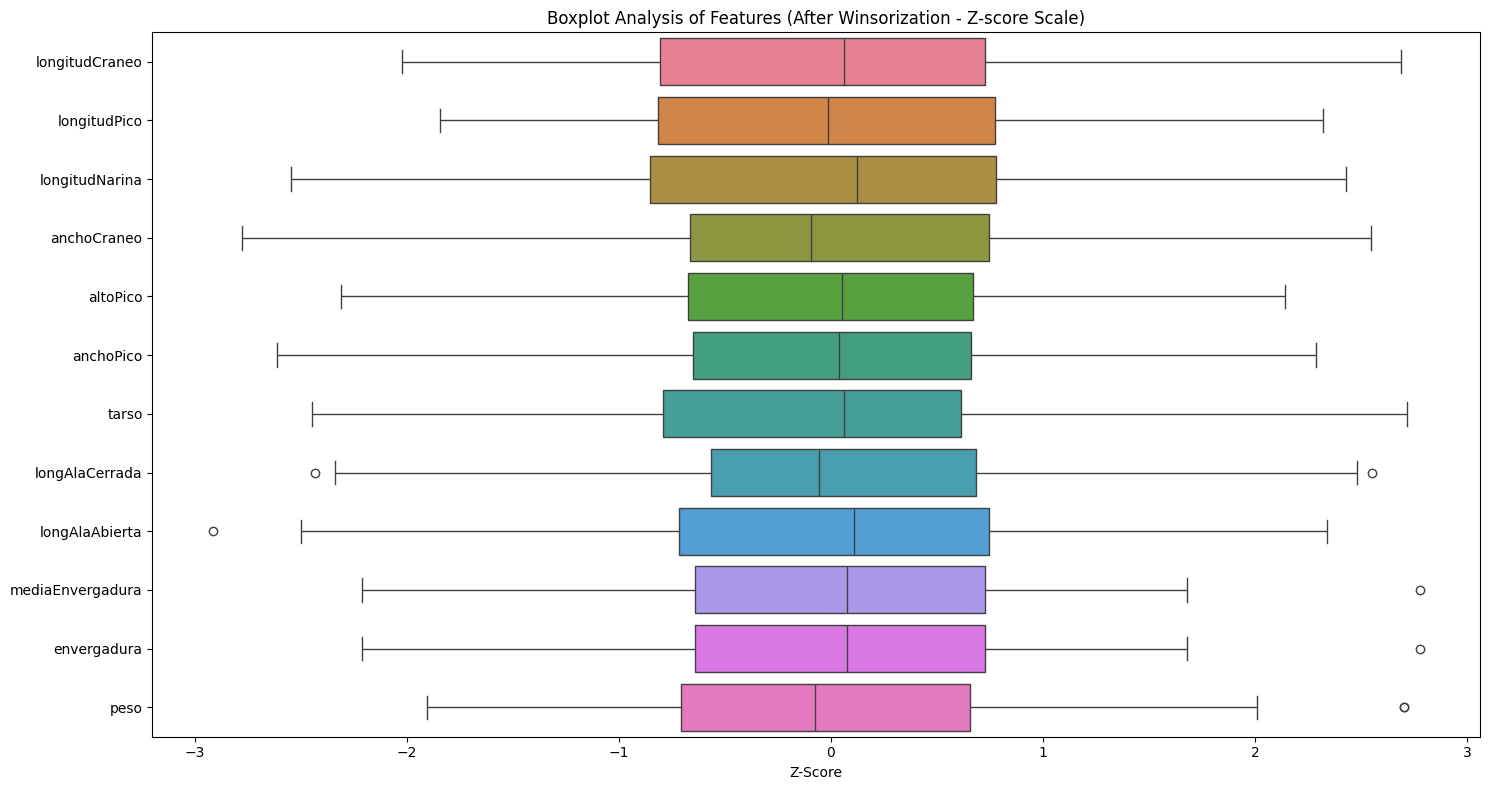

In [60]:
# Verify boxplots after capping/winsorization
plt.figure(figsize=(15, 8))
df_scaled_post = (df_train[num_cols] - df_train[num_cols].mean()) / df_train[num_cols].std()
sns.boxplot(data=df_scaled_post, orient='h')
plt.title("Boxplot Analysis of Features (After Winsorization - Z-score Scale)")
plt.xlabel("Z-Score")
plt.tight_layout()
plt.show()

In [61]:
# Extract target labels from training set
y_train = df_train['sexo']

# Extract feature matrices (dropping non-feature columns)
X_train = df_train.drop(columns=['id', 'sexo'])
X_test = df_test.drop(columns=['id'])

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (94, 12)
y_train shape: (94,)
X_test shape: (41, 12)


In [62]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical target ('H' -> 0, 'M' -> 1)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# Check class mapping
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Class mapping: {'H': np.int64(0), 'M': np.int64(1)}


In [63]:
from sklearn.preprocessing import MinMaxScaler

# 1. Initialize the Scaler
scaler = MinMaxScaler()

# 2. Fit on X_train and transform X_train
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform X_test using the parameters fitted on X_train
X_test_scaled = scaler.transform(X_test)

# Optional: Convert scaled arrays back to DataFrames to retain feature column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("X_train scaled range:", X_train_scaled.min().min(), "to", X_train_scaled.max().max())
print("X_test scaled range:", X_test_scaled.min().min(), "to", X_test_scaled.max().max())

X_train scaled range: 0.0 to 1.0000000000000009
X_test scaled range: -0.1132975551580202 to 1.0710593055013655


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Initialize Logistic Regression model
log_reg = LogisticRegression(random_state=42)

# 2. Evaluate performance using 5-Fold Stratified Cross-Validation on training data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train_encoded, cv=cv, scoring='accuracy')

print(f"5-Fold CV Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# 3. Fit the model on the entire scaled training dataset
log_reg.fit(X_train_scaled, y_train_encoded)

# 4. Make predictions on the scaled test dataset
test_preds_encoded = log_reg.predict(X_test_scaled)

# Decode predictions back to original labels ('H' and 'M')
test_preds = le.inverse_transform(test_preds_encoded)

# 5. Create and save submission DataFrame
submission = pd.DataFrame({
    'id': df_test['id'],
    'sexo': test_preds
})
submission.to_csv('submission_log_reg.csv', index=False)

print("\nSample test predictions:")
print(submission.head())

5-Fold CV Accuracy Scores: [1.         0.84210526 0.94736842 1.         0.72222222]
Mean CV Accuracy: 0.9023 (+/- 0.1069)

Sample test predictions:
         id sexo
0  A70_2018    M
1  5C9_2018    H
2  5E1_2018    H
3  C58_2018    M
4  5E2_2018    M


In [65]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Predictions on the training set
train_preds_encoded = log_reg.predict(X_train_scaled)
train_preds = le.inverse_transform(train_preds_encoded)

# 2. Accuracy Score
train_acc = accuracy_score(y_train, train_preds)
print(f"Training Accuracy: {train_acc:.4f}\n")

# 3. Confusion Matrix
cm = confusion_matrix(y_train, train_preds, labels=le.classes_)
cm_df = pd.DataFrame(cm, index=[f"Actual {c}" for c in le.classes_], columns=[f"Pred {c}" for c in le.classes_])
print("Confusion Matrix:")
print(cm_df)
print("\n" + "="*50 + "\n")

# 4. Classification Report
print("Classification Report:")
print(classification_report(y_train, train_preds))

Training Accuracy: 0.9149

Confusion Matrix:
          Pred H  Pred M
Actual H      53       4
Actual M       4      33


Classification Report:
              precision    recall  f1-score   support

           H       0.93      0.93      0.93        57
           M       0.89      0.89      0.89        37

    accuracy                           0.91        94
   macro avg       0.91      0.91      0.91        94
weighted avg       0.91      0.91      0.91        94



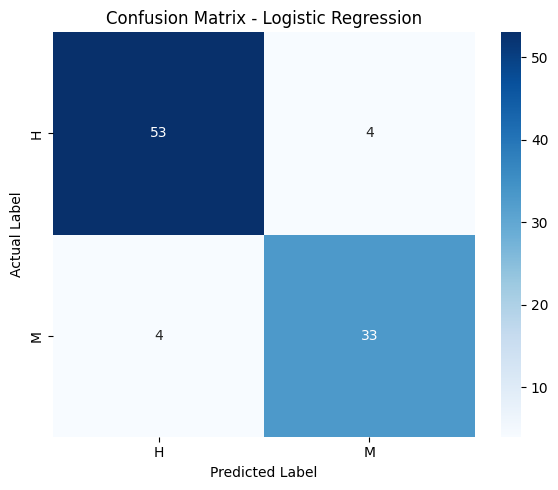

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_train, train_preds, labels=le.classes_)

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

In [67]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate overall metrics (macro and weighted averages)
metrics_summary = {
    'Accuracy': accuracy_score(y_train, train_preds),
    'Precision (Macro)': precision_score(y_train, train_preds, average='macro'),
    'Recall (Macro)': recall_score(y_train, train_preds, average='macro'),
    'F1-Score (Macro)': f1_score(y_train, train_preds, average='macro'),
    'Precision (Weighted)': precision_score(y_train, train_preds, average='weighted'),
    'Recall (Weighted)': recall_score(y_train, train_preds, average='weighted'),
    'F1-Score (Weighted)': f1_score(y_train, train_preds, average='weighted')
}

# Display overall metrics summary
df_overall = pd.DataFrame(list(metrics_summary.items()), columns=['Metric', 'Score'])
print("--- Overall Performance Metrics ---")
print(df_overall.to_string(index=False))

print("\n" + "="*45 + "\n")

# Calculate per-class metrics
precision_per_class = precision_score(y_train, train_preds, average=None, labels=le.classes_)
recall_per_class = recall_score(y_train, train_preds, average=None, labels=le.classes_)
f1_per_class = f1_score(y_train, train_preds, average=None, labels=le.classes_)

# Display per-class metrics table
df_per_class = pd.DataFrame({
    'Class': le.classes_,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class
})

print("--- Per-Class Performance Metrics ---")
print(df_per_class.to_string(index=False))

--- Overall Performance Metrics ---
              Metric    Score
            Accuracy 0.914894
   Precision (Macro) 0.910858
      Recall (Macro) 0.910858
    F1-Score (Macro) 0.910858
Precision (Weighted) 0.914894
   Recall (Weighted) 0.914894
 F1-Score (Weighted) 0.914894


--- Per-Class Performance Metrics ---
Class  Precision   Recall  F1-Score
    H   0.929825 0.929825  0.929825
    M   0.891892 0.891892  0.891892


=== DECISION TREE ===
Training Accuracy: 0.9894

Classification Report:
              precision    recall  f1-score   support

           H       0.98      1.00      0.99        57
           M       1.00      0.97      0.99        37

    accuracy                           0.99        94
   macro avg       0.99      0.99      0.99        94
weighted avg       0.99      0.99      0.99        94



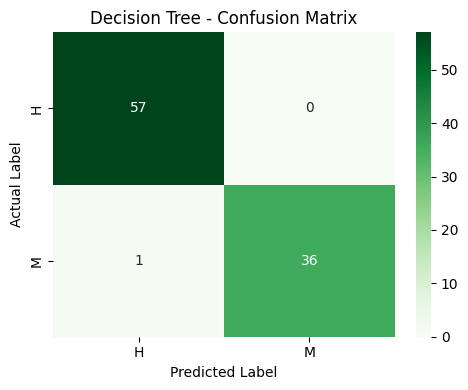


Metrics Summary:
           Metric    Score
         Accuracy 0.989362
Precision (Macro) 0.991379
   Recall (Macro) 0.986486
 F1-Score (Macro) 0.988803


In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Initialize and Fit Model
dt_model = DecisionTreeClassifier(random_state=42, max_depth=4)
dt_model.fit(X_train_scaled, y_train_encoded)

# 2. Training Predictions
train_preds_dt_enc = dt_model.predict(X_train_scaled)
train_preds_dt = le.inverse_transform(train_preds_dt_enc)

# 3. Accuracy & Classification Report
print("=== DECISION TREE ===")
print(f"Training Accuracy: {accuracy_score(y_train, train_preds_dt):.4f}\n")
print("Classification Report:")
print(classification_report(y_train, train_preds_dt))

# 4. Confusion Matrix Plot
cm_dt = confusion_matrix(y_train, train_preds_dt, labels=le.classes_)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

# 5. Metrics (Accuracy, Precision, Recall, F1-Score)
metrics_dt = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)'],
    'Score': [
        accuracy_score(y_train, train_preds_dt),
        precision_score(y_train, train_preds_dt, average='macro'),
        recall_score(y_train, train_preds_dt, average='macro'),
        f1_score(y_train, train_preds_dt, average='macro')
    ]
})
print("\nMetrics Summary:")
print(metrics_dt.to_string(index=False))

# 6. Predict on Test Set & Save Submission
test_preds_dt_enc = dt_model.predict(X_test_scaled)
test_preds_dt = le.inverse_transform(test_preds_dt_enc)
sub_dt = pd.DataFrame({'id': df_test['id'], 'sexo': test_preds_dt})
sub_dt.to_csv('submission_decision_tree.csv', index=False)

=== RANDOM FOREST ===
Training Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           H       1.00      1.00      1.00        57
           M       1.00      1.00      1.00        37

    accuracy                           1.00        94
   macro avg       1.00      1.00      1.00        94
weighted avg       1.00      1.00      1.00        94



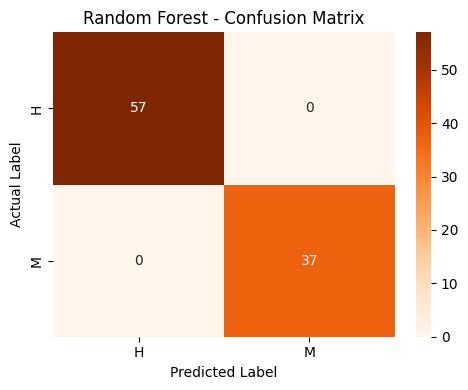


Metrics Summary:
           Metric  Score
         Accuracy    1.0
Precision (Macro)    1.0
   Recall (Macro)    1.0
 F1-Score (Macro)    1.0


In [69]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize and Fit Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train_encoded)

# 2. Training Predictions
train_preds_rf_enc = rf_model.predict(X_train_scaled)
train_preds_rf = le.inverse_transform(train_preds_rf_enc)

# 3. Accuracy & Classification Report
print("=== RANDOM FOREST ===")
print(f"Training Accuracy: {accuracy_score(y_train, train_preds_rf):.4f}\n")
print("Classification Report:")
print(classification_report(y_train, train_preds_rf))

# 4. Confusion Matrix Plot
cm_rf = confusion_matrix(y_train, train_preds_rf, labels=le.classes_)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

# 5. Metrics (Accuracy, Precision, Recall, F1-Score)
metrics_rf = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)'],
    'Score': [
        accuracy_score(y_train, train_preds_rf),
        precision_score(y_train, train_preds_rf, average='macro'),
        recall_score(y_train, train_preds_rf, average='macro'),
        f1_score(y_train, train_preds_rf, average='macro')
    ]
})
print("\nMetrics Summary:")
print(metrics_rf.to_string(index=False))

# 6. Predict on Test Set & Save Submission
test_preds_rf_enc = rf_model.predict(X_test_scaled)
test_preds_rf = le.inverse_transform(test_preds_rf_enc)
sub_rf = pd.DataFrame({'id': df_test['id'], 'sexo': test_preds_rf})
sub_rf.to_csv('submission_random_forest.csv', index=False)

=== K-NEAREST NEIGHBORS (KNN) ===
Training Accuracy: 0.9043

Classification Report:
              precision    recall  f1-score   support

           H       0.98      0.86      0.92        57
           M       0.82      0.97      0.89        37

    accuracy                           0.90        94
   macro avg       0.90      0.92      0.90        94
weighted avg       0.92      0.90      0.91        94



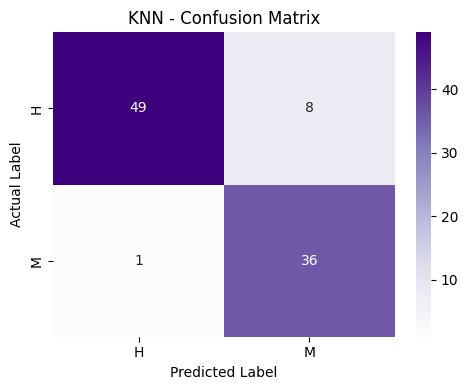


Metrics Summary:
           Metric    Score
         Accuracy 0.904255
Precision (Macro) 0.899091
   Recall (Macro) 0.916311
 F1-Score (Macro) 0.902388


In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Initialize and Fit Model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train_encoded)

# 2. Training Predictions
train_preds_knn_enc = knn_model.predict(X_train_scaled)
train_preds_knn = le.inverse_transform(train_preds_knn_enc)

# 3. Accuracy & Classification Report
print("=== K-NEAREST NEIGHBORS (KNN) ===")
print(f"Training Accuracy: {accuracy_score(y_train, train_preds_knn):.4f}\n")
print("Classification Report:")
print(classification_report(y_train, train_preds_knn))

# 4. Confusion Matrix Plot
cm_knn = confusion_matrix(y_train, train_preds_knn, labels=le.classes_)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('KNN - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

# 5. Metrics Summary (Accuracy, Precision, Recall, F1-Score)
metrics_knn = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)'],
    'Score': [
        accuracy_score(y_train, train_preds_knn),
        precision_score(y_train, train_preds_knn, average='macro'),
        recall_score(y_train, train_preds_knn, average='macro'),
        f1_score(y_train, train_preds_knn, average='macro')
    ]
})
print("\nMetrics Summary:")
print(metrics_knn.to_string(index=False))

# 6. Predict on Test Set & Save Submission
test_preds_knn_enc = knn_model.predict(X_test_scaled)
test_preds_knn = le.inverse_transform(test_preds_knn_enc)
sub_knn = pd.DataFrame({'id': df_test['id'], 'sexo': test_preds_knn})
sub_knn.to_csv('submission_knn.csv', index=False)

In [72]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Ensure all training predictions are stored explicitly
train_preds_lr = le.inverse_transform(log_reg.predict(X_train_scaled))
train_preds_dt = le.inverse_transform(dt_model.predict(X_train_scaled))
train_preds_rf = le.inverse_transform(rf_model.predict(X_train_scaled))
train_preds_knn = le.inverse_transform(knn_model.predict(X_train_scaled))

# 2. Build comparison DataFrame using macro-averaged metrics (error-proof for binary string labels)
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "K-Nearest Neighbors",
    ],
    "Accuracy": [
        accuracy_score(y_train, train_preds_lr),
        accuracy_score(y_train, train_preds_dt),
        accuracy_score(y_train, train_preds_rf),
        accuracy_score(y_train, train_preds_knn),
    ],
    "Precision": [
        precision_score(y_train, train_preds_lr, average="macro"),
        precision_score(y_train, train_preds_dt, average="macro"),
        precision_score(y_train, train_preds_rf, average="macro"),
        precision_score(y_train, train_preds_knn, average="macro"),
    ],
    "Recall": [
        recall_score(y_train, train_preds_lr, average="macro"),
        recall_score(y_train, train_preds_dt, average="macro"),
        recall_score(y_train, train_preds_rf, average="macro"),
        recall_score(y_train, train_preds_knn, average="macro"),
    ],
    "F1-Score": [
        f1_score(y_train, train_preds_lr, average="macro"),
        f1_score(y_train, train_preds_dt, average="macro"),
        f1_score(y_train, train_preds_rf, average="macro"),
        f1_score(y_train, train_preds_knn, average="macro"),
    ],
}).sort_values(by="F1-Score", ascending=False)

print(comparison_df.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1-Score
      Random Forest  1.000000   1.000000 1.000000  1.000000
      Decision Tree  0.989362   0.991379 0.986486  0.988803
Logistic Regression  0.914894   0.910858 0.910858  0.910858
K-Nearest Neighbors  0.904255   0.899091 0.916311  0.902388


In [73]:
best_f1_model = comparison_df.iloc[0]
print("Best Model based on F1-Score:")
print(best_f1_model)

Best Model based on F1-Score:
Model        Random Forest
Accuracy               1.0
Precision              1.0
Recall                 1.0
F1-Score               1.0
Name: 2, dtype: object


In [74]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Initialize the Random Forest model
best_rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Set up Stratified K-Fold CV (5 Folds)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Calculate Cross-Validation Accuracy scores across all folds
cv_acc_scores = cross_val_score(best_rf_model, X_train_scaled, y_train_encoded, cv=skf, scoring='accuracy')

# 4. Generate out-of-fold predictions to compute macro-averaged metrics
oof_preds_encoded = cross_val_predict(best_rf_model, X_train_scaled, y_train_encoded, cv=skf)
oof_preds = le.inverse_transform(oof_preds_encoded)

# 5. Display Stratified K-Fold Results
print("=== STRATIFIED K-FOLD CROSS-VALIDATION (RANDOM FOREST) ===")
print(f"Fold Accuracy Scores: {np.round(cv_acc_scores, 4)}")
print(f"Mean CV Accuracy:     {cv_acc_scores.mean():.4f} (+/- {cv_acc_scores.std():.4f})\n")

# Summary DataFrame for CV Metrics
cv_summary_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Macro)", "Recall (Macro)", "F1-Score (Macro)"],
    "Score": [
        accuracy_score(y_train, oof_preds),
        precision_score(y_train, oof_preds, average="macro"),
        recall_score(y_train, oof_preds, average="macro"),
        f1_score(y_train, oof_preds, average="macro")
    ]
})

print("Cross-Validation Metrics Summary:")
print(cv_summary_df.to_string(index=False))

=== STRATIFIED K-FOLD CROSS-VALIDATION (RANDOM FOREST) ===
Fold Accuracy Scores: [0.9474 0.6842 0.8947 1.     0.7222]
Mean CV Accuracy:     0.8497 (+/- 0.1247)

Cross-Validation Metrics Summary:
           Metric    Score
         Accuracy 0.851064
Precision (Macro) 0.844002
   Recall (Macro) 0.844002
 F1-Score (Macro) 0.844002


In [75]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# 2. Set up Stratified K-Fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Initialize Base Model and GridSearchCV
rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

# 4. Perform Grid Search on full training data
grid_search.fit(X_train_scaled, y_train_encoded)

# 5. Output Best Parameters and Best CV Score
print("=== HYPERPARAMETER TUNING (GRID SEARCH) RESULTS ===")
print("Best Hyperparameters found:")
for param, val in grid_search.best_params_.items():
    print(f"  {param}: {val}")

print(f"\nBest Cross-Validation F1-Score (Macro): {grid_search.best_score_:.4f}")

# 6. Evaluate Best Model on Training Set
best_rf = grid_search.best_estimator_
train_preds_best_enc = best_rf.predict(X_train_scaled)
train_preds_best = le.inverse_transform(train_preds_best_enc)

tuned_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Macro)", "Recall (Macro)", "F1-Score (Macro)"],
    "Score": [
        accuracy_score(y_train, train_preds_best),
        precision_score(y_train, train_preds_best, average="macro"),
        recall_score(y_train, train_preds_best, average="macro"),
        f1_score(y_train, train_preds_best, average="macro")
    ]
})

print("\nTuned Model Training Performance:")
print(tuned_metrics_df.to_string(index=False))

# 7. Predict on Test Set with Tuned Model & Save Submission
test_preds_best_enc = best_rf.predict(X_test_scaled)
test_preds_best = le.inverse_transform(test_preds_best_enc)

submission_tuned = pd.DataFrame({
    'id': df_test['id'],
    'sexo': test_preds_best
})
submission_tuned.to_csv('submission_random_forest_tuned.csv', index=False)
print("\nSaved tuned predictions to 'submission_random_forest_tuned.csv'")

=== HYPERPARAMETER TUNING (GRID SEARCH) RESULTS ===
Best Hyperparameters found:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 50

Best Cross-Validation F1-Score (Macro): 0.8516

Tuned Model Training Performance:
           Metric  Score
         Accuracy    1.0
Precision (Macro)    1.0
   Recall (Macro)    1.0
 F1-Score (Macro)    1.0

Saved tuned predictions to 'submission_random_forest_tuned.csv'


In [76]:
# Extract best estimator from grid search
best_model = grid_search.best_estimator_

# Predict on the scaled test set
best_pred_encoded = best_model.predict(X_test_scaled)

# Decode numerical predictions back to original string labels ('H', 'M')
best_pred = le.inverse_transform(best_pred_encoded)

# Create and save submission DataFrame
submission_best = pd.DataFrame({
    'id': df_test['id'],
    'sexo': best_pred
})
submission_best.to_csv('submission_best_model.csv', index=False)
print("Saved best model predictions to 'submission_best_model.csv'")

Saved best model predictions to 'submission_best_model.csv'


In [77]:
#dummytest

In [78]:
import pandas as pd

# 1. Define custom input features (replace values with your actual feature measurements)
sample_data = pd.DataFrame([{
    'longitudCraneo': 175.0,
    'longitudPico': 108.0,
    'longitudNarina': 81.0,
    'anchoCraneo': 52.0,
    'altoPico': 31.0,
    'anchoPico': 25.0,
    'tarso': 90.0,
    'longAlaCerrada': 51.5,
    'longAlaAbierta': 96.0,
    'mediaEnvergadura': 105.0,
    'envergadura': 210.0,
    'peso': 2.6
}])

# 2. Scale features using the fitted scaler
sample_scaled = scaler.transform(sample_data)

# 3. Predict class with the best tuned model
sample_pred_encoded = best_model.predict(sample_scaled)
sample_pred = le.inverse_transform(sample_pred_encoded)

# 4. Display predicted sex label ('H' or 'M')
print("Predicted Sex:", sample_pred[0])

Predicted Sex: H


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
